In [101]:
import networkx as nx 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import re, pickle, powerlaw, urllib.request, json, time
from collections import Counter
download = False # Set true if you wish to re-download

In [102]:
def get_category_members(url, page_name):
    base_url = f'https://{url}/api.php?'
    query = (
        f"{base_url}"
        f"action=query&list=categorymembers&cmtitle={urllib.parse.quote(page_name)}"
        f"&cmlimit=max&format=json"
    )
    request = urllib.request.Request(query)
    request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')
    with urllib.request.urlopen(request) as response:
        wikidata = json.loads(response.read())
        return [member['title'] for member in wikidata['query']['categorymembers']]


def extract_characters_and_categories(response, downloaded_categories):
    # Words that indicate non-character categories
    blacklist = ['places', 'creatures', 'locations', 'objects', 'languages',
                 'rivers', 'mountains', 'events', 'battles', 'wars', 'books',
                 'families', 'songs', 'terms', 'legends', 'real-world', 'media', 
                 'non-canonical', 'images', 'ranks', 'titles']
    
    characters = []
    categories = []

    for title in response:
        if title.startswith('Category:'):
            # Normalize for comparison
            lower = title.lower()
            if any(bad in lower for bad in blacklist):
                continue  # skip non-character categories
            if title not in downloaded_categories:
                categories.append(title)
        else:
            # Keep only likely character pages (heuristic: no colon, not "Category:", not image)
            if ':' not in title and not title.lower().startswith('list of'):
                characters.append(title)
    return list(set(characters)), list(set(categories))


def get_all_characters(url, root_category='Category:Characters'):
    downloaded_categories = [root_category]
    response = get_category_members(url, root_category)
    characters, categories = extract_characters_and_categories(response, downloaded_categories)

    while categories:
        current = categories.pop(0)
        downloaded_categories.append(current)
        #print(f"{len(categories)} remaining. Fetching: {current}")
        response = get_category_members(url, current)
        char, cat = extract_characters_and_categories(response, downloaded_categories)
        characters = list(set(characters + char))
        categories = list(set(categories))# + cat))
        time.sleep(0.5)

    return sorted(set(characters))

def download_pages(url, page_names, batch_size=25):
    api_url = f'https://{url}/api.php'
    results = []

    for i in range(0, len(page_names), batch_size):
        batch = page_names[i:i+batch_size]
        clean_batch = [t for t in batch if t and not any(c in t for c in '\n\r{}')]
        if not clean_batch:
            continue

        data = {
            'action': 'query',
            'prop': 'revisions',
            'rvprop': 'content',
            'titles': '|'.join(clean_batch),
            'format': 'json'
        }

        encoded = urllib.parse.urlencode(data).encode('utf-8')
        request = urllib.request.Request(api_url, data=encoded)
        request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')

        try:
            with urllib.request.urlopen(request) as response:
                wikidata = json.loads(response.read())
                for key, page in wikidata['query']['pages'].items():
                    revisions = page.get('revisions', [{}])
                    content = revisions[0].get('*', '') if revisions else ''
                    results.append({
                        'page_name': page.get('title', ''),
                        'content': content
                    })
        except urllib.error.HTTPError as e:
            print(f"HTTP Error {e.code} on batch {i//batch_size + 1}: {e.reason}")
        time.sleep(0.3)
    return results



if download:
    url             = 'lotr.fandom.com'
    category_name   = 'Category:Characters'
    page_names      = get_all_characters(url, category_name)
    print(f'There are {len(page_names)} characters in Lord of the Rings')
    print(f'First 10 pages:\n {page_names[10:]}')

    lotr_pages = download_pages(url, page_names)
    with open("lotr_characters.pkl", "wb") as f:   # 'wb' = write binary
        pickle.dump(lotr_pages, f)


In [103]:
def extract_infobox(content):
    # Step 1: find the starting point of the infobox
    start_match = re.search(r"\{\{[^{}]{0,50}?[Ii]nfobox", content, flags=re.IGNORECASE)
    if not start_match:
        return None

    start_index = start_match.start()

    # Step 2: walk forward and find the matching braces
    brace_count = 0
    i = start_index
    while i < len(content):
        if content[i:i+2] == "{{":
            brace_count += 1
            i += 2
            continue
        elif content[i:i+2] == "}}":
            brace_count -= 1
            i += 2
            if brace_count == 0:
                return content[start_index:i]  # extract full infobox
            continue
        else:
            i += 1

    return None  # fallback if somehow unbalanced

def extract_field(text, field):
    lines = text.splitlines()
    capture = False
    genre_lines = []
    for line in lines:
        if not capture:
            if re.match(rf'\|\s*{field}\s*=', line, flags=re.I):
                line = re.sub(rf'\|\s*{field}\s*=\s*', '', line, flags=re.I)
                genre_lines.append(line)
                capture = True
        else:
            if re.match(r'\|\s*\w+\s*=', line):
                break
            genre_lines.append(line)
    return '\n'.join(genre_lines).strip()

def extract_name(text):
    pattern = r"\[\[(.*?)\]\]"
    matches = re.findall(pattern, text)
    return matches

def extract_origin(text, field):
    return extract_name(extract_field(extract_infobox(text), field))

# Declare helper functions
def clean_links(links, node):
    arr = []
    for l in links:
        match = re.search(r'|', l)
        if match:
            splits = l.split(r'|')
            if splits[0].replace(' ', '_') == node: #Remove self-loops
                continue
            else:
                arr.append(splits[0].replace(' ', '_'))
        else:
            if l.replace(' ', '_') == node:
                continue
            else:
                arr.append(l.replace(' ', '_'))
    return arr

def analyze_node(data_point, field_origin, field_species):
    Node = data_point['page_name']
    text = data_point['content']
    words = len(text.split())
    try:
        origin = extract_origin(text, field_origin)
    except:
        origin = None

    try:
        species = extract_origin(text, field_species)
    except:
        species = None
    links_to = re.findall(r'\[\[([^\]]+)\]\]', text)
    links_to = clean_links(links_to, Node)
    return Node, links_to, words, origin, species

def create_network(data, field_origin, field_species, use_only_largest_component = True):
    for entry in data:
        entry['page_name'] = entry['page_name'].replace(' ','_')
    G = nx.DiGraph()
    non_links = []
    Nodes = list(set([data_point['page_name'] for data_point in data]))
    for data_point in data:
        Node, links_to, words, origin, species = analyze_node(data_point, field_origin, field_species)
        G.add_node(Node, words=words, origin = origin, species = species)
        for links_to_node in links_to:
            if links_to_node in Nodes:
                G.add_edge(Node, links_to_node)
            else:
                non_links.append(links_to_node)

    G = G.subgraph([node for node, deg in G.degree() if deg > 0])
    if use_only_largest_component:
        # Extract the largest component
        components = nx.weakly_connected_components(G)
        largest = max(components, key=len)
        G = G.subgraph(largest).copy()
    
    return G

In [104]:
def print_data(data):
    N = len(data)
    total_n_words = 0
    for entry in data:
        total_n_words += len(entry['content'].split())
    print(f'There are {N:,} pages in the wiki-data source and a total of {total_n_words:,} words on all of the pages combined. Words/Pages: {total_n_words/N:.0f}\n')

def printy(G):
    print(
        f"Number of nodes: {len(G.nodes())}.\n"
        f"Number of Edges: {len(G.edges())}.\n"
        f"Average degree: {np.average([deg for _, deg in G.degree()]):.2f}.\n"
        f"Average clustering: {nx.average_clustering(G):.2f}.\n"
        f"Average number of words: {np.mean([data['words'] for _, data in G.nodes(data=True)]):.2f}"
    )

def create_centrality_table(G, top = 10):
    in_degree               = [node for node, _ in sorted([(node, degree) for node, degree in G.in_degree()], key = lambda x: x[1], reverse = True)[:top]]
    out_degree              = [node for node, _ in sorted([(node, degree) for node, degree in G.out_degree()], key = lambda x: x[1], reverse = True)[:top]]
    degree_centrality       = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.degree_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    betweenness_centrality  = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.betweenness_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    eigenvector_centrality  = [node for node, _ in sorted([(node, centrality) for node, centrality in nx.eigenvector_centrality(G).items()], key = lambda x: x[1], reverse = True)[:top]]
    words                   = [node for node, _ in sorted([(node, data['words']) for node, data in G.nodes(data=True)], key = lambda x: x[1], reverse = True)[:top]]

    print(f"{'Rank':<5} {'In-degree':>30} {'Out-degree':>30} {'Degree centrality':>30} {'Betweenness centrality':>30} {'Eigenvector centrality':>30} {'Length of content':>30}")
    print('-' * 200)
    for i in range(len(degree_centrality)):
        print(f'{i+1:<5} {in_degree[i]:>30} {out_degree[i]:>30} {degree_centrality[i]:>30} {betweenness_centrality[i]:>30} {eigenvector_centrality[i]:>30} {words[i]:>30}')

def plot_degree_distributions(G, bins=30, title = 'Degree Distributions'):
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.titlesize": 16
    })
    

    in_deg = [deg for _, deg in G.in_degree() if deg > 0]
    alpha_in = powerlaw.Fit(in_deg).alpha
    out_deg = [deg for _, deg in G.out_degree() if deg > 0]
    alpha_out = powerlaw.Fit(out_deg).alpha
    deg = [deg for _, deg in G.degree() if deg > 0]
    alpha = powerlaw.Fit(deg).alpha

    # Define shared bin edges
    in_max = max(in_deg)
    out_max = max(out_deg)

    in_bins = np.linspace(0, in_max, bins+1)
    out_bins = np.linspace(0, out_max, bins+1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    # In-degree plots (shared bins)
    axes[0].hist(in_deg, bins=in_bins, color="#1f77b4", alpha=0.8, edgecolor="black")
    axes[0].set_title(f"In-degree distribution \nDegree exponent (alpha): {alpha_in:.2f}")

    axes[1].hist(out_deg, bins=out_bins, color="#ff7f0e", alpha=0.8, edgecolor="black")
    axes[1].set_title(f"Out-degree distribution \nDegree exponent (alpha): {alpha_out:.2f}")

    axes[2].hist(deg, bins=out_bins, color="#00c22a", alpha=0.8, edgecolor="black")
    axes[2].set_title(f"Total degree distribution \nDegree exponent (alpha): {alpha:.2f}")

    fig.suptitle(title, fontsize=18, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def disparity_filter(G, alpha_threshold):
    # Create an empty graph of the same type
    backbone = G.__class__()
    backbone.add_nodes_from(G.nodes(data=True))

    # Compute normalized weights and significance for each node
    for i in G.nodes():
        k_i = len(G[i])
        if k_i <= 1:
            continue

        s_i = sum(G[i][j].get('viz_weight', 1.0) for j in G[i])
        for j in G[i]:
            w_ij = G[i][j].get('viz_weight', 1.0)
            p_ij = w_ij / s_i
            alpha_ij = 1 - (1 - p_ij) ** (k_i - 1)
            G[i][j]['alpha_' + str(i)] = alpha_ij

    # For undirected graphs, use the maximum significance (conservative choice)
    if not G.is_directed():
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            alpha_j = data.get('alpha_' + str(j), 1)
            alpha = min(alpha_i, alpha_j)
            if alpha < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha})
    else:
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            if alpha_i < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha_i})

    return backbone


def normalize(x, min_, max_):
    return (x - min_) / (max_ - min_) * 100

def plot_backbone(G, alpha_threshold=0.5, node_size=50, edge_width=1,
                  nodes_cmap=plt.cm.viridis, edge_cmap=plt.cm.Blues, title = ''):
    G = G.copy()

    plt.figure(figsize=(10,10))

    # Compute betweenness-based visualization weights
    betweenness = nx.edge_betweenness_centrality(G)
    min_bw, max_bw = min(betweenness.values()), max(betweenness.values())
    for (u, v), w in betweenness.items():
        G[u][v]['viz_weight'] = normalize(w, min_bw, max_bw)

    # Extract backbone
    backbone = disparity_filter(G, alpha_threshold)
    
    # Remove nodes with degree less than 5
    to_remove = [n for n, d in backbone.degree() if d < 5]
    backbone.remove_nodes_from(to_remove)

    components = nx.connected_components(backbone)
    largest = max(components, key=len)
    backbone = backbone.subgraph(largest).copy()

    # Compute node centrality
    centrality = nx.betweenness_centrality(backbone)
    min_c, max_c = min(centrality.values()), max(centrality.values())
    values = [normalize(centrality[n], min_c, max_c) for n in backbone.nodes()]
    # Layout
    try:
        pos = nx.forceatlas2_layout(backbone, seed = 42)
    except:
        pos = nx.spring_layout(backbone, seed = 42)

    weights = [G[u][v].get('viz_weight', 1.0) for u, v in backbone.edges()]
    
    # Draw edges
    nx.draw_networkx_edges(backbone, pos, width=edge_width,
                           edge_color='grey', alpha=0.4)

    # Draw nodes
    nx.draw_networkx_nodes(backbone, pos, node_size=[v + node_size for v in values],
                           node_color=values, cmap=nodes_cmap, alpha=1)

    if len(title) == 0:
        title = f"Network Backbone ({backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges)"
    plt.axis("off")
    plt.title(title, fontsize = 22)
    plt.show()

def print_attribute(G, attribute, top_n = 5):
    arr = [ data[attribute][0] if data[attribute] else 'None' for _, data in G.nodes(data=True) ]
    distinct_attributes = set(arr)
    print(f'Distinct {attribute}s: {len(distinct_attributes)}')
    print(f'\nTop {top_n} {attribute}s')
    print(f'{"Rank":<5} {f"{attribute}":>30} {"Count":>40}')
    print('-'*80)
    counts = Counter(arr)
    top = counts.most_common(top_n)
    for i, (att, count) in enumerate(top):
        print(f'{i+1:<5} {att:>30} {count:>40}')

Which universe has a more centralized social structure?

Based on degree, betweenness, eigenvector centrality, and structural properties, Harry Potter shows a significantly more centralized social network than Lord of the Rings.

The Harry Potter graph has fewer nodes (506) and fewer total connections (1765), but the interactions are dominated by a very small set of characters. Harry, Dumbledore, Hermione, Ron, Severus Snape, and Tom Riddle consistently occupy the top positions across all centrality measures. This concentration indicates a strongly core-dominated structure where narrative and social interactions revolve around a few highly connected individuals.

In contrast, the Lord of the Rings network is larger (877 nodes) and much denser (6238 edges, average degree 14.23). Although certain figures such as Sauron, Gandalf, Morgoth, and Aragorn are highly central, the rankings spread across many groups: Elves, Dwarves, Valar, Men, Mordor forces, and members of the Fellowship. The higher clustering coefficient (0.42) and the presence of 44 distinct species also illustrate LOTR’s modular and multi-community structure. No single character dominates all centrality measures, and the story spans several regions and ages.



To investigate and compatere the social structure of the networks we calculate degree, betweennes and eigenvector centrality for the two networks, see table X. 

To investigate and compatere the social structure of the networks we calculate different centrality measures. Firstly for the Harry Potter network we find that the centrality measures of interactions are dominated by a small group of characters, namely Harry Potter, Albus Dumbledore, Hermione Granger, Ronald Weasley, Severus Snape and Tom Riddle (Voldemort). From the betweeness centrality it is clear that they act as connectors between otherwise unrelated characters and from the eigenvector centrality we see that they are connected to other influential nodes. This indicates that the mentioned characters are the core of the structure, where about the interactions and narrative are centralized. 

This pattern is the same for the Lord of the Rings network. Here we see that characters such as Sauron, Gandalf, Saruman, Galadriel, Elrond, Aragorn II and the Valar are central in all centrality measures. 

However, to see how the centrality of the networks differ we ...




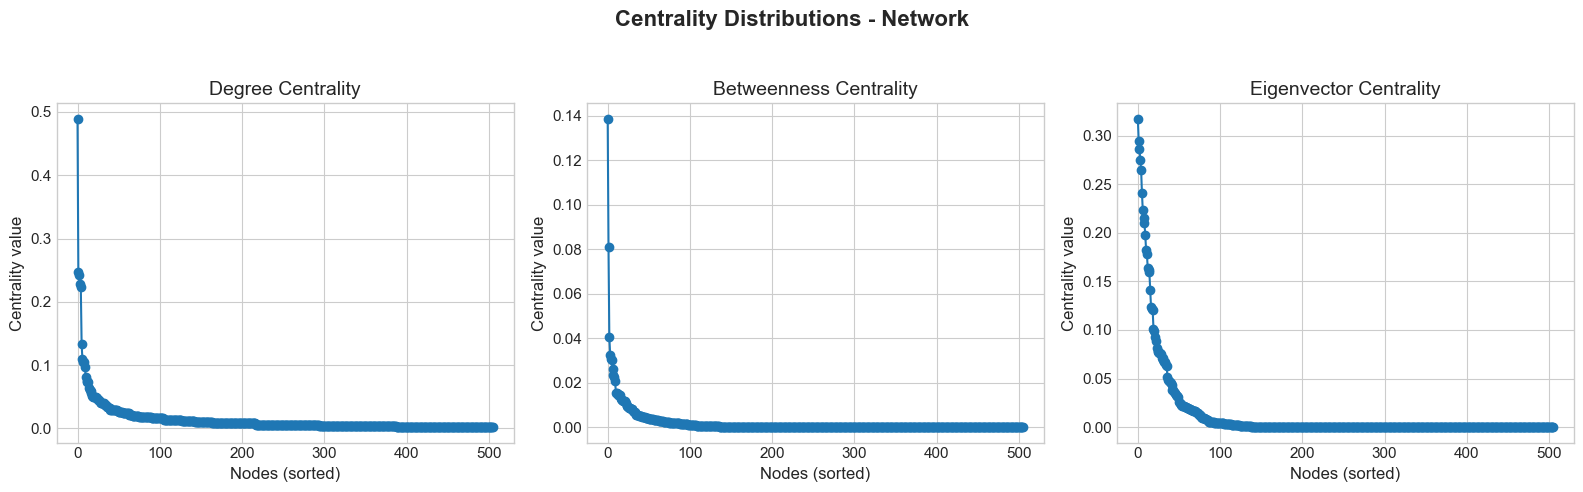


Top 10 nodes by Degree Centrality (Network):
Harry_Potter: 0.4891
Albus_Dumbledore: 0.2475
Tom_Riddle: 0.2416
Ronald_Weasley: 0.2277
Hermione_Granger: 0.2238
Severus_Snape: 0.1327
Neville_Longbottom: 0.1089
Alastor_Moody: 0.1050
William_Weasley: 0.1050
Nymphadora_Tonks: 0.0970

Top 10 nodes by Betweenness Centrality (Network):
Harry_Potter: 0.1385
Albus_Dumbledore: 0.0809
Phineas_Nigellus_Black: 0.0406
Ronald_Weasley: 0.0326
Hermione_Granger: 0.0304
Neville_Longbottom: 0.0303
Tom_Riddle: 0.0260
Daniel_Page: 0.0235
Niamh_Fitzgerald: 0.0224
Severus_Snape: 0.0206

Top 10 nodes by Eigenvector Centrality (Network):
Harry_Potter: 0.3174
Tom_Riddle: 0.2947
Albus_Dumbledore: 0.2868
Ronald_Weasley: 0.2747
Hermione_Granger: 0.2644
Severus_Snape: 0.2408
Bellatrix_Lestrange: 0.2234
Neville_Longbottom: 0.2157
Alastor_Moody: 0.2099
Ginevra_Weasley: 0.1979


In [113]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_centrality_distributions(G, network_name="Network"):
    measures = {
        "Degree": nx.degree_centrality(G),
        "Betweenness": nx.betweenness_centrality(G),
        "Eigenvector": nx.eigenvector_centrality(G, max_iter=1000)
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for i, (name, centrality) in enumerate(measures.items()):
        sorted_vals = sorted(centrality.values(), reverse=True)
        axes[i].plot(sorted_vals, marker='o')
        axes[i].set_title(f"{name} Centrality")
        axes[i].set_xlabel("Nodes (sorted)")
        axes[i].set_ylabel("Centrality value")
    
    fig.suptitle(f"Centrality Distributions - {network_name}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    
    # Optional: print top nodes
    for name, centrality in measures.items():
        top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\nTop 10 nodes by {name} Centrality ({network_name}):")
        for node, value in top_nodes:
            print(f"{node}: {value:.4f}")

plot_centrality_distributions(HP_network)


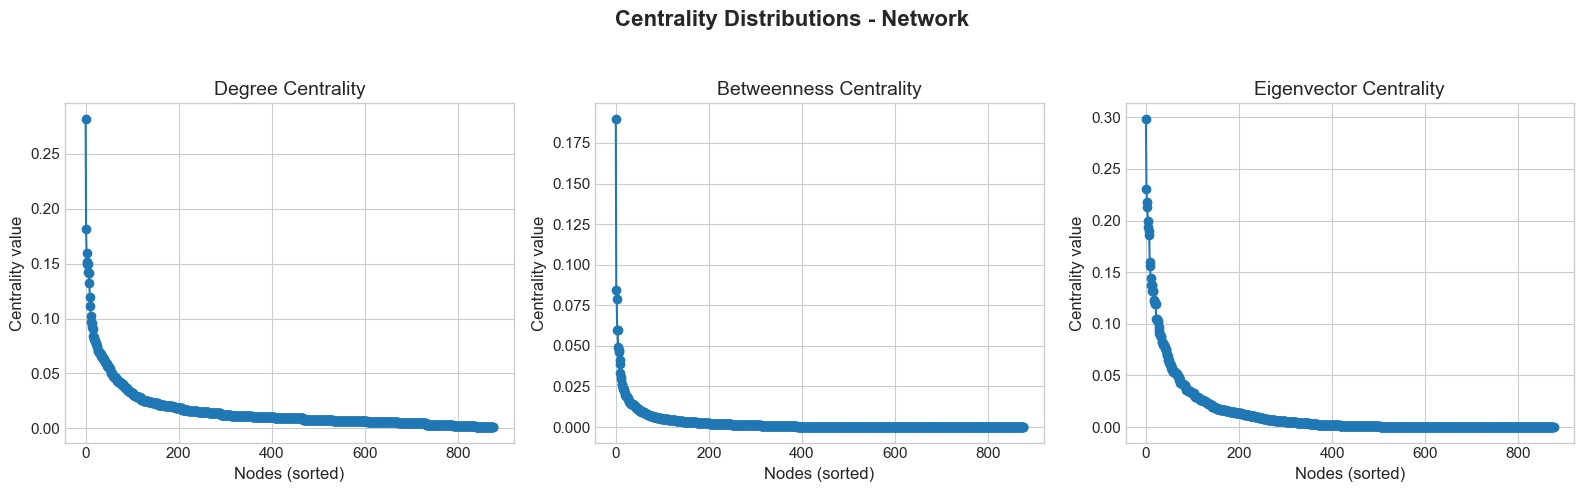


Top 10 nodes by Degree Centrality (Network):
Sauron: 0.2820
Gandalf: 0.1815
Morgoth: 0.1598
Galadriel: 0.1518
Valar: 0.1495
Aragorn_II: 0.1495
Elrond: 0.1427
Saruman: 0.1416
Edain: 0.1324
Frodo_Baggins: 0.1199

Top 10 nodes by Betweenness Centrality (Network):
Sauron: 0.1898
Aragorn_II: 0.0844
Morgoth: 0.0786
Gandalf: 0.0600
Galadriel: 0.0597
Edain: 0.0495
Elrond: 0.0477
Saruman: 0.0465
Valar: 0.0411
Isildur: 0.0388

Top 10 nodes by Eigenvector Centrality (Network):
Sauron: 0.2984
Gandalf: 0.2309
Aragorn_II: 0.2182
Elrond: 0.2132
Valar: 0.1999
Galadriel: 0.1938
Saruman: 0.1898
Frodo_Baggins: 0.1856
Nazgûl: 0.1597
Dark_Lord: 0.1557


In [114]:
plot_centrality_distributions(LOTR_network)

There are 998 pages in the wiki-data source and a total of 868,983 words on all of the pages combined. Words/Pages: 871

Number of nodes: 506.
Number of Edges: 1765.
Average degree: 6.98.
Average clustering: 0.39.
Average number of words: 1513.22

Rank                       In-degree                     Out-degree              Degree centrality         Betweenness centrality         Eigenvector centrality              Length of content
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                       Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter                   Harry_Potter
2                         Tom_Riddle               Albus_Dumbledore               Albus_Dumbledore               Albus_Dumbledore                     Tom_Riddle       

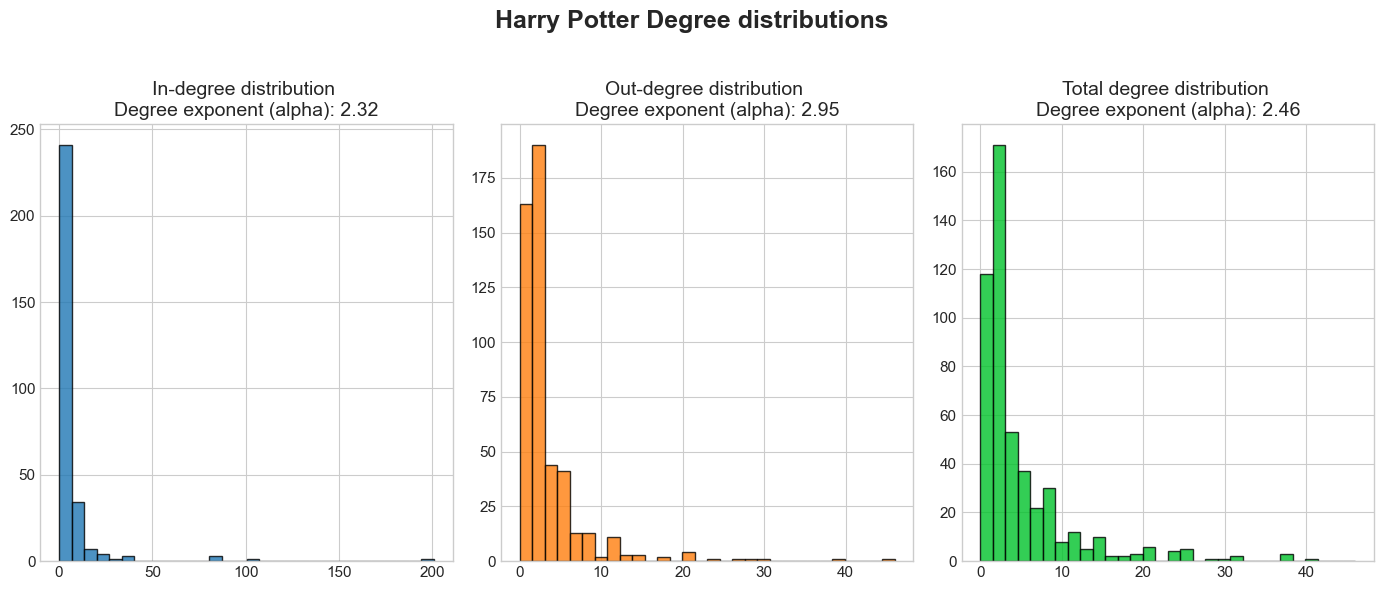

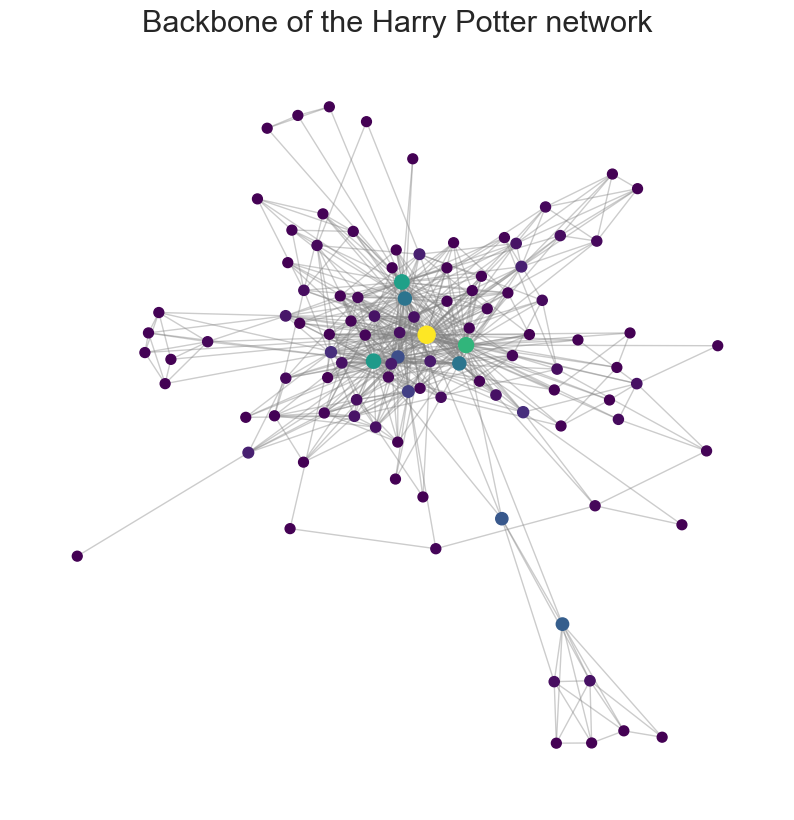

In [11]:
with open("hp_characters.pkl", "rb") as f:   # 'rb' = read binary
    HP_data = pickle.load(f)
    
HP_network = create_network(HP_data, field_origin = 'house', field_species = 'species')
print_data(HP_data)
printy(HP_network)
print()
create_centrality_table(HP_network)
print()
print_attribute(HP_network, 'species')
print()
print_attribute(HP_network, 'origin')
print()
plot_degree_distributions(HP_network, title = 'Harry Potter Degree distributions')
plot_backbone(HP_network.to_undirected().copy(), alpha_threshold=0.8, title = 'Backbone of the Harry Potter network')

There are 895 pages in the wiki-data source and a total of 711,845 words on all of the pages combined. Words/Pages: 795

Number of nodes: 877.
Number of Edges: 6238.
Average degree: 14.23.
Average clustering: 0.42.
Average number of words: 807.63

Rank                       In-degree                     Out-degree              Degree centrality         Betweenness centrality         Eigenvector centrality              Length of content
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                             Sauron                         Sauron                         Sauron                         Sauron                         Sauron                         Sauron
2                              Valar                        Morgoth                        Gandalf                     Aragorn_II                        Gandalf       

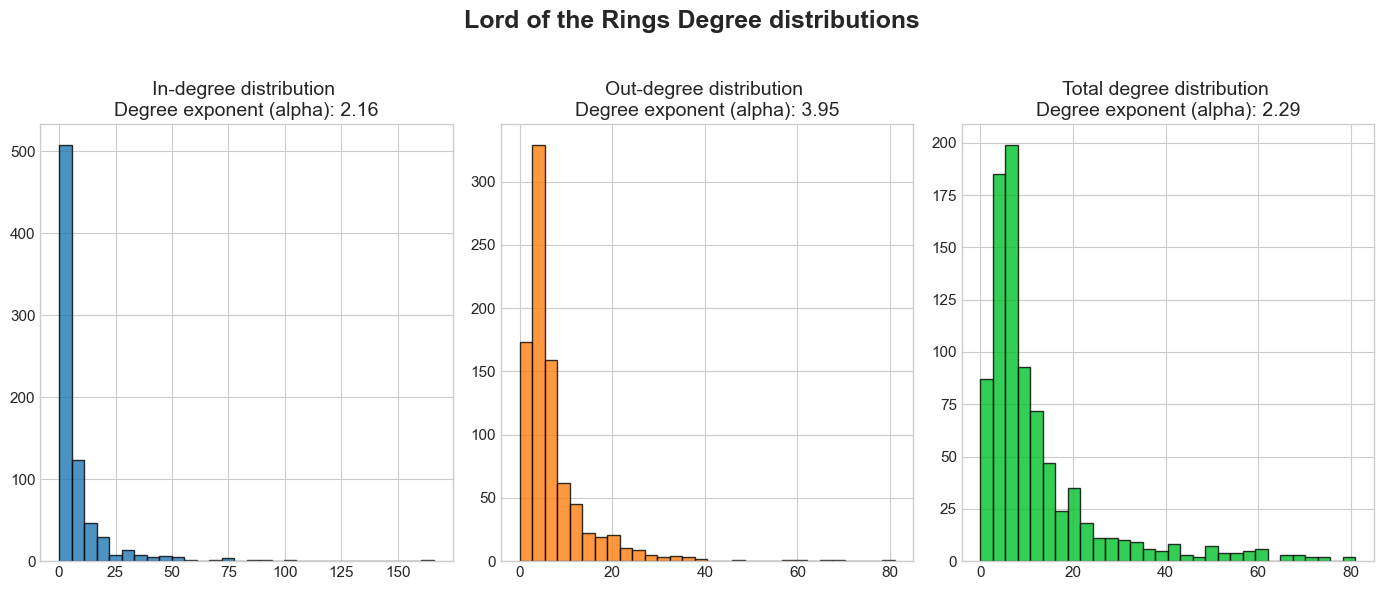

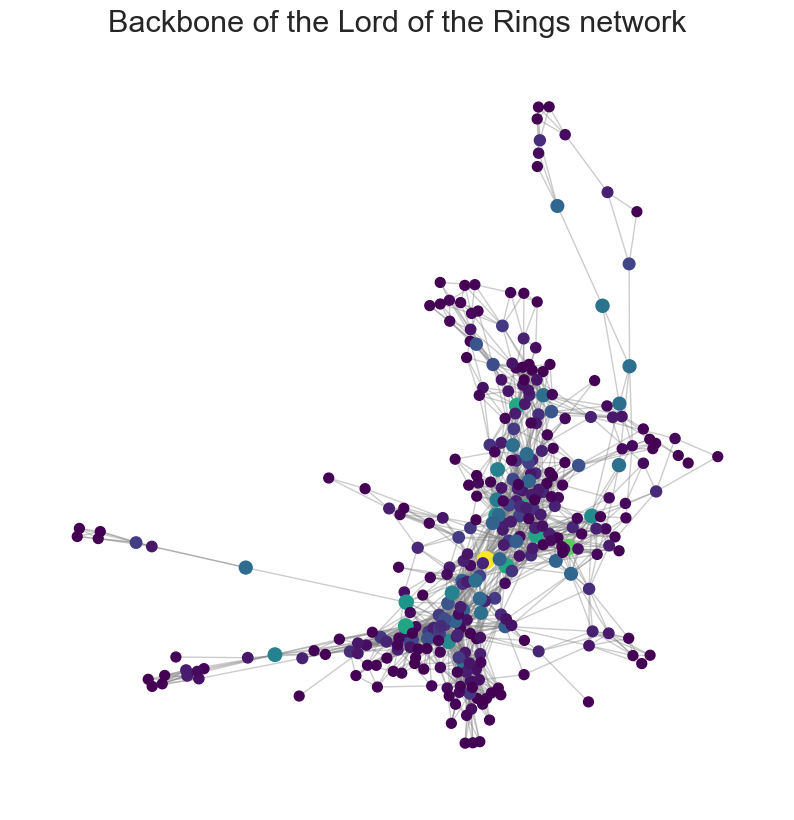

In [12]:
with open("lotr_characters.pkl", "rb") as f:   # 'rb' = read binary
    LOTR_data = pickle.load(f)

LOTR_network = create_network(LOTR_data, field_origin = 'culture', field_species = 'race')
print_data(LOTR_data)
printy(LOTR_network)
print()
create_centrality_table(LOTR_network)
print()
print_attribute(LOTR_network, 'species')
print()
print_attribute(LOTR_network, 'origin')
print()
plot_degree_distributions(LOTR_network, title = 'Lord of the Rings Degree distributions')
plot_backbone(LOTR_network.to_undirected().copy(), alpha_threshold=0.4, title = 'Backbone of the Lord of the Rings network')

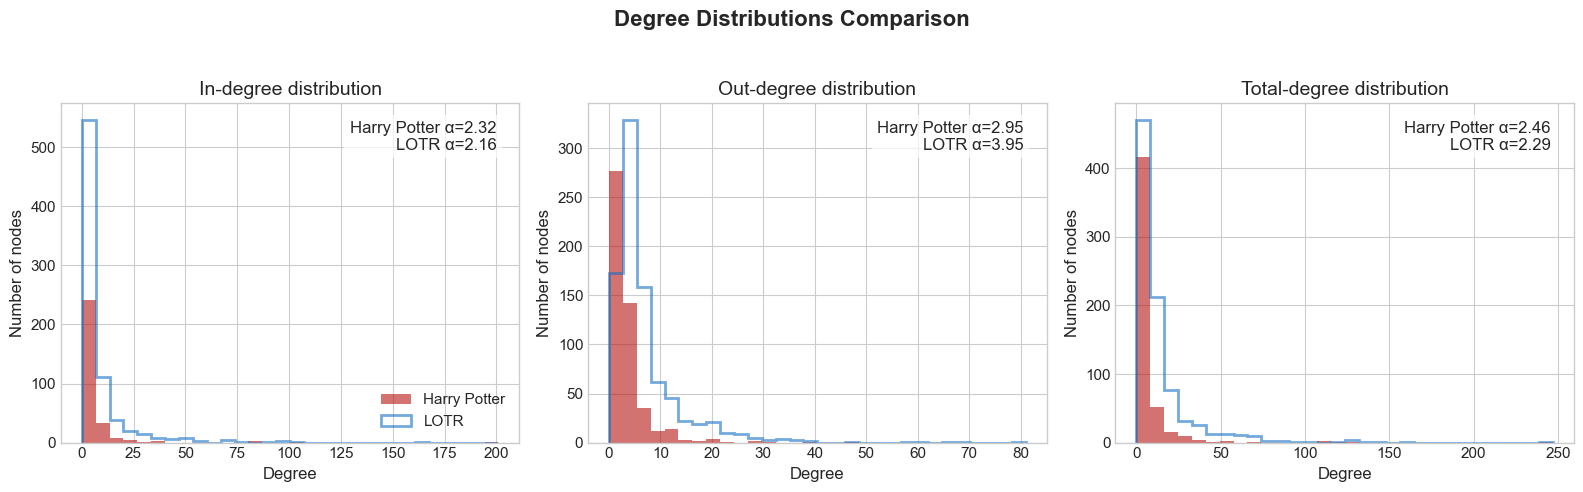

In [108]:
import matplotlib.pyplot as plt
import numpy as np
import powerlaw

def compare_degree_distributions(G1, G2, label1="Harry Potter", label2="LOTR", bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    
    colors = {label1: "#b51512", label2: "#1670c4"}
    deg_types = ["in", "out", "total"]
    
    # Extract degree lists
    degs1 = {
        "in": [deg for _, deg in G1.in_degree() if deg>0],
        "out": [deg for _, deg in G1.out_degree() if deg>0],
        "total": [deg for _, deg in G1.degree() if deg>0]
    }
    degs2 = {
        "in": [deg for _, deg in G2.in_degree() if deg>0],
        "out": [deg for _, deg in G2.out_degree() if deg>0],
        "total": [deg for _, deg in G2.degree() if deg>0]
    }
    
    alphas1 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs1.items()}
    alphas2 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs2.items()}
    
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    
    for i, dtype in enumerate(deg_types):
        max_deg = max(max(degs1[dtype]), max(degs2[dtype]))
        bins_arr = np.linspace(0, max_deg, bins+1)
        
        # Plot histograms
        axes[i].hist(degs1[dtype], bins=bins_arr, alpha=0.6, color=colors[label1], label=label1)
        axes[i].hist(degs2[dtype], bins=bins_arr, alpha=0.6, color=colors[label2], label=label2, 
                     histtype='step', linewidth=2)
        
        axes[i].set_xlabel("Degree")
        axes[i].set_ylabel("Number of nodes")
        axes[i].set_title(f"{dtype.capitalize()}-degree distribution")
        
        # Only show legend on first subplot, lower-right corner
        if i == 0:
            axes[i].legend(loc='lower right')
        
        # Alpha text in top-right corner
        axes[i].text(0.95, 0.95, f"{label1} α={alphas1[dtype]:.2f}\n{label2} α={alphas2[dtype]:.2f}", 
                     transform=axes[i].transAxes,
                     verticalalignment='top',
                     horizontalalignment='right',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    fig.suptitle("Degree Distributions Comparison", fontsize=16, weight='bold')
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()

compare_degree_distributions(HP_network, LOTR_network, label1="Harry Potter", label2="LOTR")


In [49]:
import networkx as nx

def freeman_centralization(centrality_dict):
    """
    Compute Freeman centralization for any node centrality dict.
    Centrality values should be normalized (0–1).
    """
    n = len(centrality_dict)
    max_c = max(centrality_dict.values())
    return sum(max_c - c for c in centrality_dict.values()) / (n - 1)

# --- LOTR network ---
G_lotr = LOTR_network  # replace with your network variable
deg_cent_lotr = nx.degree_centrality(G_lotr)
bet_cent_lotr = nx.betweenness_centrality(G_lotr, normalized=True)
eig_cent_lotr = nx.eigenvector_centrality(G_lotr, max_iter=1000)

# Freeman centralization
deg_centralization_lotr = freeman_centralization(deg_cent_lotr)
bet_centralization_lotr = freeman_centralization(bet_cent_lotr)
eig_centralization_lotr = freeman_centralization(eig_cent_lotr)

# --- Harry Potter network ---
G_hp = HP_network  # replace with your network variable
deg_cent_hp = nx.degree_centrality(G_hp)
bet_cent_hp = nx.betweenness_centrality(G_hp, normalized=True)
eig_cent_hp = nx.eigenvector_centrality(G_hp, max_iter=1000)

# Freeman centralization
deg_centralization_hp = freeman_centralization(deg_cent_hp)
bet_centralization_hp = freeman_centralization(bet_cent_hp)
eig_centralization_hp = freeman_centralization(eig_cent_hp)

# --- Print results ---
print("Freeman Centralization (LOTR):")
print(f"Degree: {deg_centralization_lotr:.4f}")
print(f"Betweenness: {bet_centralization_lotr:.4f}")
print(f"Eigenvector: {eig_centralization_lotr:.4f}\n")

print("Freeman Centralization (Harry Potter):")
print(f"Degree: {deg_centralization_hp:.4f}")
print(f"Betweenness: {bet_centralization_hp:.4f}")
print(f"Eigenvector: {eig_centralization_hp:.4f}")


Freeman Centralization (LOTR):
Degree: 0.2660
Betweenness: 0.1873
Eigenvector: 0.2855

Freeman Centralization (Harry Potter):
Degree: 0.4762
Betweenness: 0.1370
Eigenvector: 0.3051


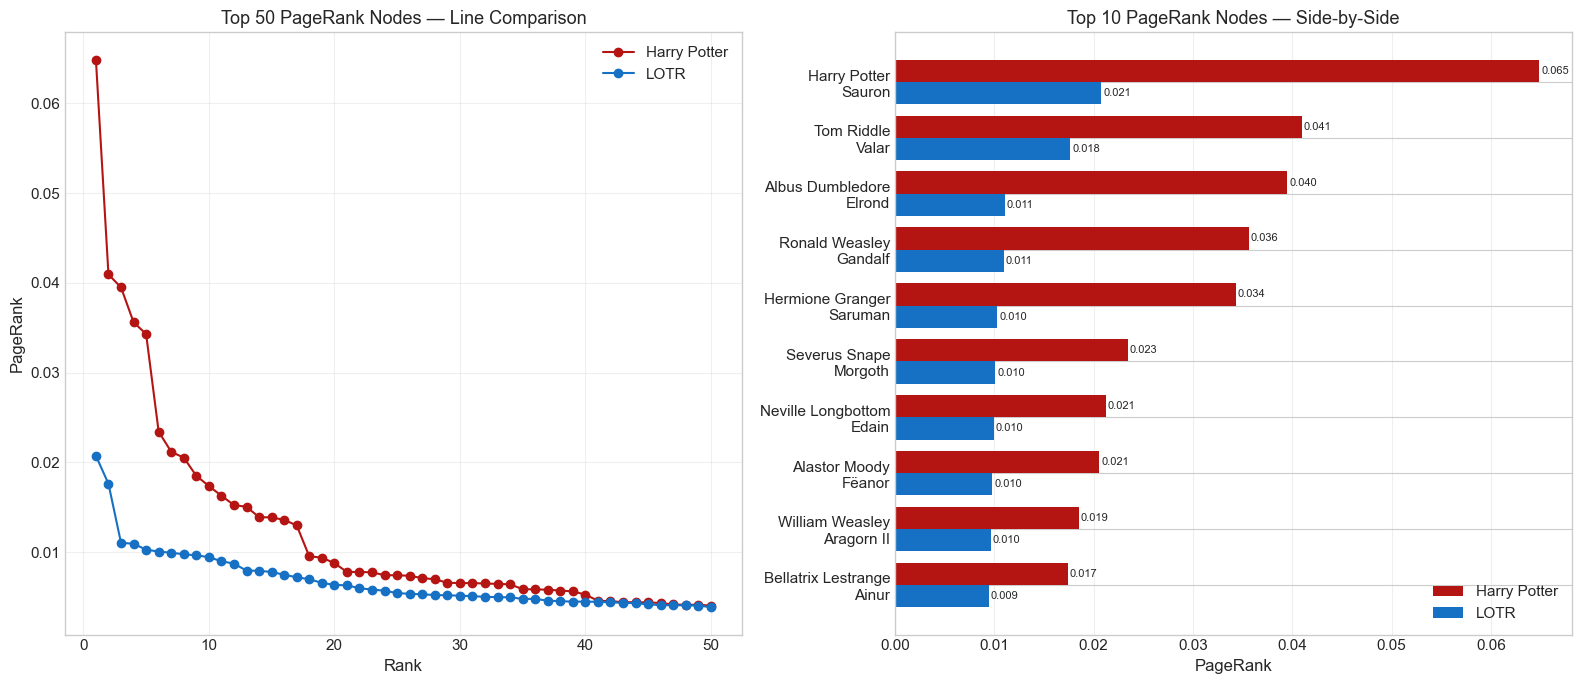

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Helper functions ----------
def clean_name(name):
    return name.replace("_", " ")

def get_top(pr, n):
    top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:n]
    names = [clean_name(node) for node, _ in top]
    scores = [score for _, score in top]
    return names, scores

# ---------- Get data ----------
top_n_line = 50
top_n_bar = 10

# Line plot values
top_hp_line = sorted(pr_HP.items(), key=lambda x: x[1], reverse=True)[:top_n_line]
top_lotr_line = sorted(pr_LOTR.items(), key=lambda x: x[1], reverse=True)[:top_n_line]

hp_scores_line = [v for _, v in top_hp_line]
lotr_scores_line = [v for _, v in top_lotr_line]

# Bar plot values
names_hp_bar, scores_hp_bar = get_top(pr_HP, top_n_bar)
names_lotr_bar, scores_lotr_bar = get_top(pr_LOTR, top_n_bar)

# Reverse for horizontal bars
names_hp_bar = names_hp_bar[::-1]
scores_hp_bar = scores_hp_bar[::-1]
names_lotr_bar = names_lotr_bar[::-1]
scores_lotr_bar = scores_lotr_bar[::-1]

# ---------- Create figure ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# =====================================================
#                 LEFT: Top-50 LINE PLOT
# =====================================================
ax1.plot(range(1, top_n_line + 1), hp_scores_line, marker='o',
         label="Harry Potter", color="#b51512")
ax1.plot(range(1, top_n_line + 1), lotr_scores_line, marker='o',
         label="LOTR", color="#1670c4")

ax1.set_title("Top 50 PageRank Nodes — Line Comparison", fontsize=13)
ax1.set_xlabel("Rank")
ax1.set_ylabel("PageRank")
ax1.legend()
ax1.grid(alpha=0.3)


# =====================================================
#                 RIGHT: Top-10 BAR PLOT
# =====================================================
ind = np.arange(top_n_bar)
width = 0.4

ax2.barh(ind + width/2, scores_hp_bar, height=width, label="Harry Potter", color="#b51512")
ax2.barh(ind - width/2, scores_lotr_bar, height=width, label="LOTR", color="#1670c4")

# Combined y-tick labels (HP over LOTR)
combined_labels = [f"{hp}\n{lotr}" for hp, lotr in zip(names_hp_bar, names_lotr_bar)]
ax2.set_yticks(ind)
ax2.set_yticklabels(combined_labels)

# Add values
for i in range(top_n_bar):
    ax2.text(scores_hp_bar[i] + 0.0002, ind[i] + width/2, f"{scores_hp_bar[i]:.3f}",
             va='center', fontsize=8)
    ax2.text(scores_lotr_bar[i] + 0.0002, ind[i] - width/2, f"{scores_lotr_bar[i]:.3f}",
             va='center', fontsize=8)

ax2.set_title("Top 10 PageRank Nodes — Side-by-Side", fontsize=13)
ax2.set_xlabel("PageRank")
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [116]:
import networkx as nx
import numpy as np

def core_periphery_fit(G):
    """
    Estimate a core-periphery fit score for network G.
    Returns:
        fit_score (float): 0-1, higher means a clearer core-periphery structure.
        core_nodes (list): nodes in the core
        periphery_nodes (list): nodes in the periphery
    """
    # Step 1: Use k-core decomposition to find core nodes
    core_numbers = nx.core_number(G)
    max_core = max(core_numbers.values())
    core_nodes = [n for n, k in core_numbers.items() if k == max_core]
    periphery_nodes = [n for n in G.nodes() if n not in core_nodes]

    # Step 2: Build ideal core-periphery adjacency matrix
    A = nx.to_numpy_array(G, nodelist=list(G.nodes()))
    ideal = np.zeros_like(A)
    node_idx = {n: i for i, n in enumerate(G.nodes())}

    # Core-core connections = 1
    for u in core_nodes:
        for v in core_nodes:
            if u != v:
                ideal[node_idx[u], node_idx[v]] = 1

    # Core-periphery connections = 1 if edge exists
    for u in core_nodes:
        for v in periphery_nodes:
            if G.has_edge(u, v) or G.has_edge(v, u):
                ideal[node_idx[u], node_idx[v]] = 1
                ideal[node_idx[v], node_idx[u]] = 1

    # Periphery-periphery connections = 0 ideally
    # Step 3: Compute fit = correlation between adjacency and ideal
    A_flat = A.flatten()
    ideal_flat = ideal.flatten()
    fit_score = np.corrcoef(A_flat, ideal_flat)[0,1]

    return fit_score, core_nodes, periphery_nodes


# --- Example usage ---
fit_hp, core_hp, periphery_hp = core_periphery_fit(HP_network)
fit_lotr, core_lotr, periphery_lotr = core_periphery_fit(LOTR_network)

print(f"Harry Potter network core-periphery fit: {fit_hp:.3f}")
print(f"LOTR network core-periphery fit: {fit_lotr:.3f}")

print(f"Number of core nodes HP: {len(core_hp)}, LOTR: {len(core_lotr)}")


Harry Potter network core-periphery fit: 0.592
LOTR network core-periphery fit: 0.410
Number of core nodes HP: 13, LOTR: 23


    hertil har jeg ryddet op
    

In [ ]:
#assortativity 
import networkx as nx

degree_assortativity_LOTR = nx.degree_assortativity_coefficient(LOTR_network)
print("Degree assortativity LOTR:", degree_assortativity_LOTR)

words_assortativity_LOTR = nx.attribute_assortativity_coefficient(LOTR_network, "words")
print("Words (content length) assortativity LOTR:", words_assortativity_LOTR)

degree_assortativity_HP = nx.degree_assortativity_coefficient(HP_network)
print("Degree assortativity HP:", degree_assortativity_HP)

words_assortativity_HP = nx.attribute_assortativity_coefficient(HP_network, "words")
print("Words (content length) assortativity HP:", words_assortativity_HP)




Degree assortativity LOTR: 0.03459538617553729
Words (content length) assortativity LOTR: -0.003364174478717982
Degree assortativity HP: -0.14910877903534148
Words (content length) assortativity HP: -0.010197556374032113


^^ assosativity close to 0, means no no dependence of links and length of content - characters with long wiki-pages are no more likely to link to each other. 

HP: Degree assortativity: characters with high degree are more likely to connect to characters with low degree? 

In [55]:
from collections import Counter

species_counter = Counter()

for _, data in LOTR_network.nodes(data=True):
    species = data.get("species", [])
    
    # Skip None
    if species is None:
        continue
    
    # Ensure it's a list
    if isinstance(species, str):
        species = [species]
    
    # Count each species
    species_counter.update(species)

# Get the 20 most common species
most_common_20 = species_counter.most_common(20)

print("20 most common species in the network:")
for species, count in most_common_20:
    print(f"{species}: {count}")


20 most common species in the network:
Men: 377
Elves: 108
Dwarves: 39
Ainur: 32
Hobbits: 28
Half-elves: 16
Orcs: 15
Hobbits|Hobbit: 7
Dragons: 6
Uruk-hai: 5
Men|mortal: 4
Elves|Elf: 4
Ents: 4
Half-elves|Half-elf: 3
men|mortal: 3
Harfoots: 3
Orc: 3
Cats: 3
Elves|immortal: 2
Valar: 2


In [56]:
import networkx as nx

# Define normalization mapping
normalize_species = {
    'men': 'Men',
    'hobbit': 'Hobbits',
    'hobbits': 'Hobbits',
    'half-elf': 'Half-elves',
    'half-elves': 'Half-elves',
    'elves': 'Elves',
    'elf': 'Elves',
    'uruk-hai': 'Uruk-hai',
    'orc': 'Orcs',
    'orcs': 'Orcs',
    'dwarves': 'Dwarves',
    'dragon': 'Dragons',
    'dragons': 'Dragons',
    'ent': 'Ents',
    'ents': 'Ents',
    'valar': 'Valar',
    'cats': 'Cats',
    # add more if needed
}

# Build a normalized species dictionary
species_attr = {}
for n, data in LOTR_network.nodes(data=True):
    species = data.get("species", [])
    if species is None:
        species_list = []
    elif isinstance(species, str):
        species_list = [species]
    else:
        species_list = species

    # Take the first species that matches mapping
    canonical = 'Other'
    for s in species_list:
        s_lower = s.lower().split('|')[0]  # handle "Men|mortal" -> "men"
        if s_lower in normalize_species:
            canonical = normalize_species[s_lower]
            break
    species_attr[n] = canonical

# Assign as node attribute
nx.set_node_attributes(LOTR_network, species_attr, name='species_canonical')

# Compute assortativity
assortativity = nx.attribute_assortativity_coefficient(LOTR_network, 'species_canonical')
print("Assortativity by species (canonicalized):", assortativity)


Assortativity by species (canonicalized): 0.3666578717391888


In [57]:
from collections import Counter

# Define normalization mapping
normalize_species = {
    'men': 'Men',
    'hobbit': 'Hobbits',
    'hobbits': 'Hobbits',
    'half-elf': 'Half-elves',
    'half-elves': 'Half-elves',
    'elves': 'Elves',
    'elf': 'Elves',
    'uruk-hai': 'Uruk-hai',
    'orc': 'Orcs',
    'orcs': 'Orcs',
    'dwarves': 'Dwarves',
    'dragon': 'Dragons',
    'dragons': 'Dragons',
    'ent': 'Ents',
    'ents': 'Ents',
    'valar': 'Valar',
    'cats': 'Cats',
    # add more if needed
}

species_counter = Counter()

for _, data in LOTR_network.nodes(data=True):
    species = data.get("species", [])
    
    # Handle None
    if species is None:
        species_list = []
    elif isinstance(species, str):
        species_list = [species]
    else:
        species_list = species

    # Map to canonical species
    canonical = 'Other'
    for s in species_list:
        s_lower = s.lower().split('|')[0]  # take first part before '|'
        if s_lower in normalize_species:
            canonical = normalize_species[s_lower]
            break
    
    species_counter[canonical] += 1

# Show the counts
print("Canonical species counts:")
for species, count in species_counter.most_common():
    print(f"{species}: {count}")


Canonical species counts:
Men: 378
Other: 260
Elves: 110
Dwarves: 39
Hobbits: 31
Half-elves: 19
Orcs: 18
Dragons: 6
Ents: 6
Uruk-hai: 5
Cats: 3
Valar: 2


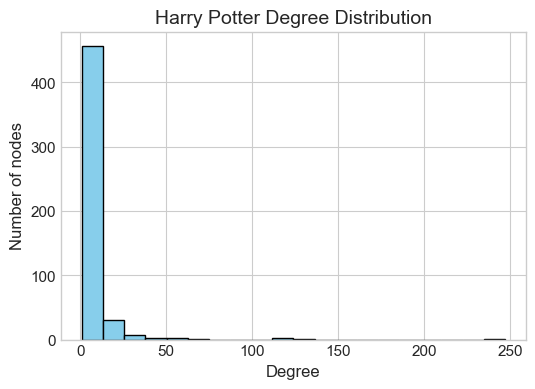

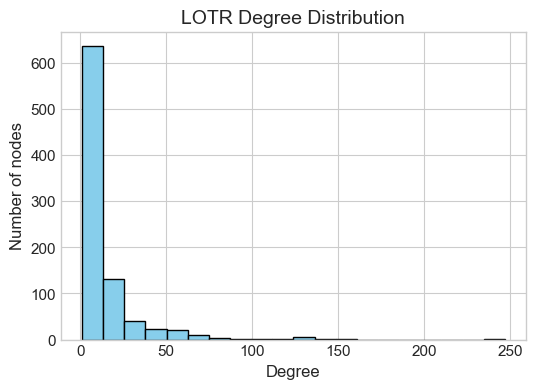

              Nodes  Edges  Avg Degree  Avg Clustering  Degree Centralization  \
Harry Potter    506   1765    6.976285        0.390619               0.476236   
LOTR            877   6238   14.225770        0.415747               0.266027   

              Betweenness Centralization  Eigenvector Centralization  \
Harry Potter                    0.136993                    0.305125   
LOTR                            0.187313                    0.285482   

              Gini Degree  Gini Betweenness  
Harry Potter     0.629700          0.910797  
LOTR             0.540221          0.836933  


In [51]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# --- Helper function: Freeman centralization ---
def freeman_centralization(centrality_dict):
    """Compute Freeman centralization for any centrality dict (values normalized 0-1)."""
    n = len(centrality_dict)
    max_c = max(centrality_dict.values())
    return sum(max_c - c for c in centrality_dict.values()) / (n - 1)

# --- Helper function: Gini coefficient ---
def gini(array):
    """Compute Gini coefficient of a numpy array"""
    array = np.array(array)
    if np.all(array == 0):
        return 0.0
    array = np.sort(array)
    n = array.shape[0]
    cumvals = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

# --- Analysis function ---
def analyze_network(G, name="Network"):
    n_nodes = len(G.nodes)
    n_edges = len(G.edges)
    avg_degree = sum(dict(G.degree()).values()) / n_nodes
    avg_clustering = nx.average_clustering(G)
    
    # Centrality metrics
    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G, normalized=True)
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    
    # Freeman centralization
    deg_centralization = freeman_centralization(deg_cent)
    bet_centralization = freeman_centralization(bet_cent)
    eig_centralization = freeman_centralization(eig_cent)
    
    # Gini coefficients (hierarchy measure)
    gini_degree = gini(list(dict(G.degree()).values()))
    gini_bet = gini(list(bet_cent.values()))
    
    # Degree distribution plot
    degrees = [d for _, d in G.degree()]
    plt.figure(figsize=(6,4))
    plt.hist(degrees, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{name} Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Number of nodes")
    plt.show()
    
    # Summary dictionary
    summary = {
        "Nodes": n_nodes,
        "Edges": n_edges,
        "Avg Degree": avg_degree,
        "Avg Clustering": avg_clustering,
        "Degree Centralization": deg_centralization,
        "Betweenness Centralization": bet_centralization,
        "Eigenvector Centralization": eig_centralization,
        "Gini Degree": gini_degree,
        "Gini Betweenness": gini_bet
    }
    
    return summary, deg_cent, bet_cent, eig_cent

# --- Run analysis for both networks ---
summary_HP, deg_HP, bet_HP, eig_HP = analyze_network(HP_network, "Harry Potter")
summary_LOTR, deg_LOTR, bet_LOTR, eig_LOTR = analyze_network(LOTR_network, "LOTR")

# --- Print summary table ---
import pandas as pd
df = pd.DataFrame([summary_HP, summary_LOTR], index=["Harry Potter", "LOTR"])
print(df[["Nodes","Edges","Avg Degree","Avg Clustering",
         "Degree Centralization","Betweenness Centralization",
         "Eigenvector Centralization","Gini Degree","Gini Betweenness"]])


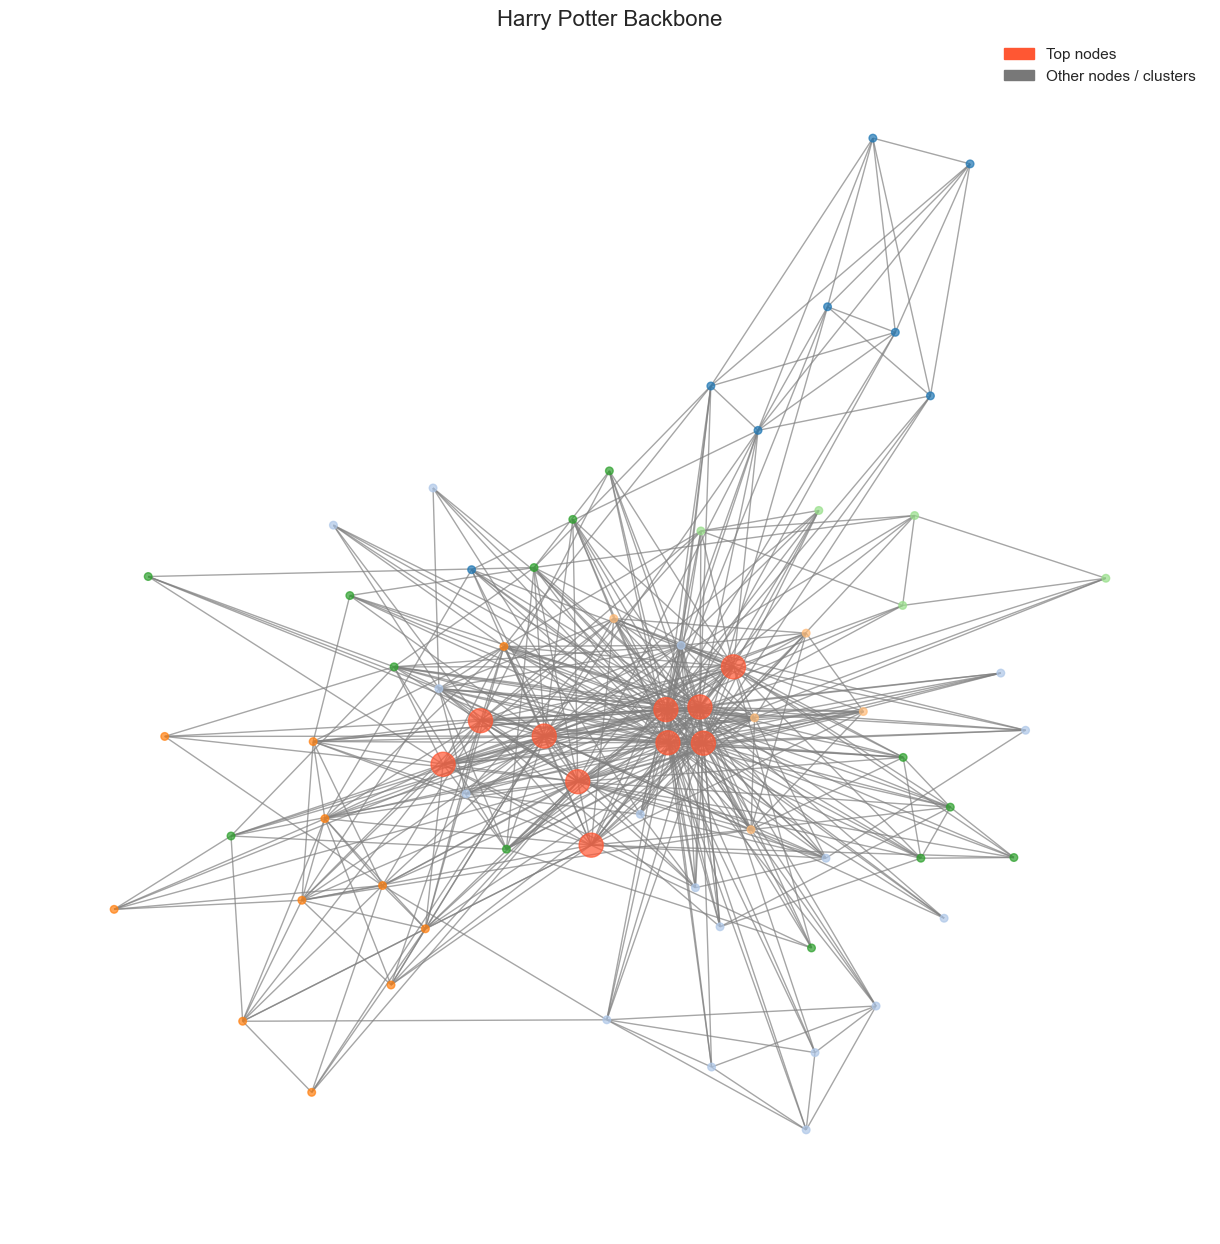

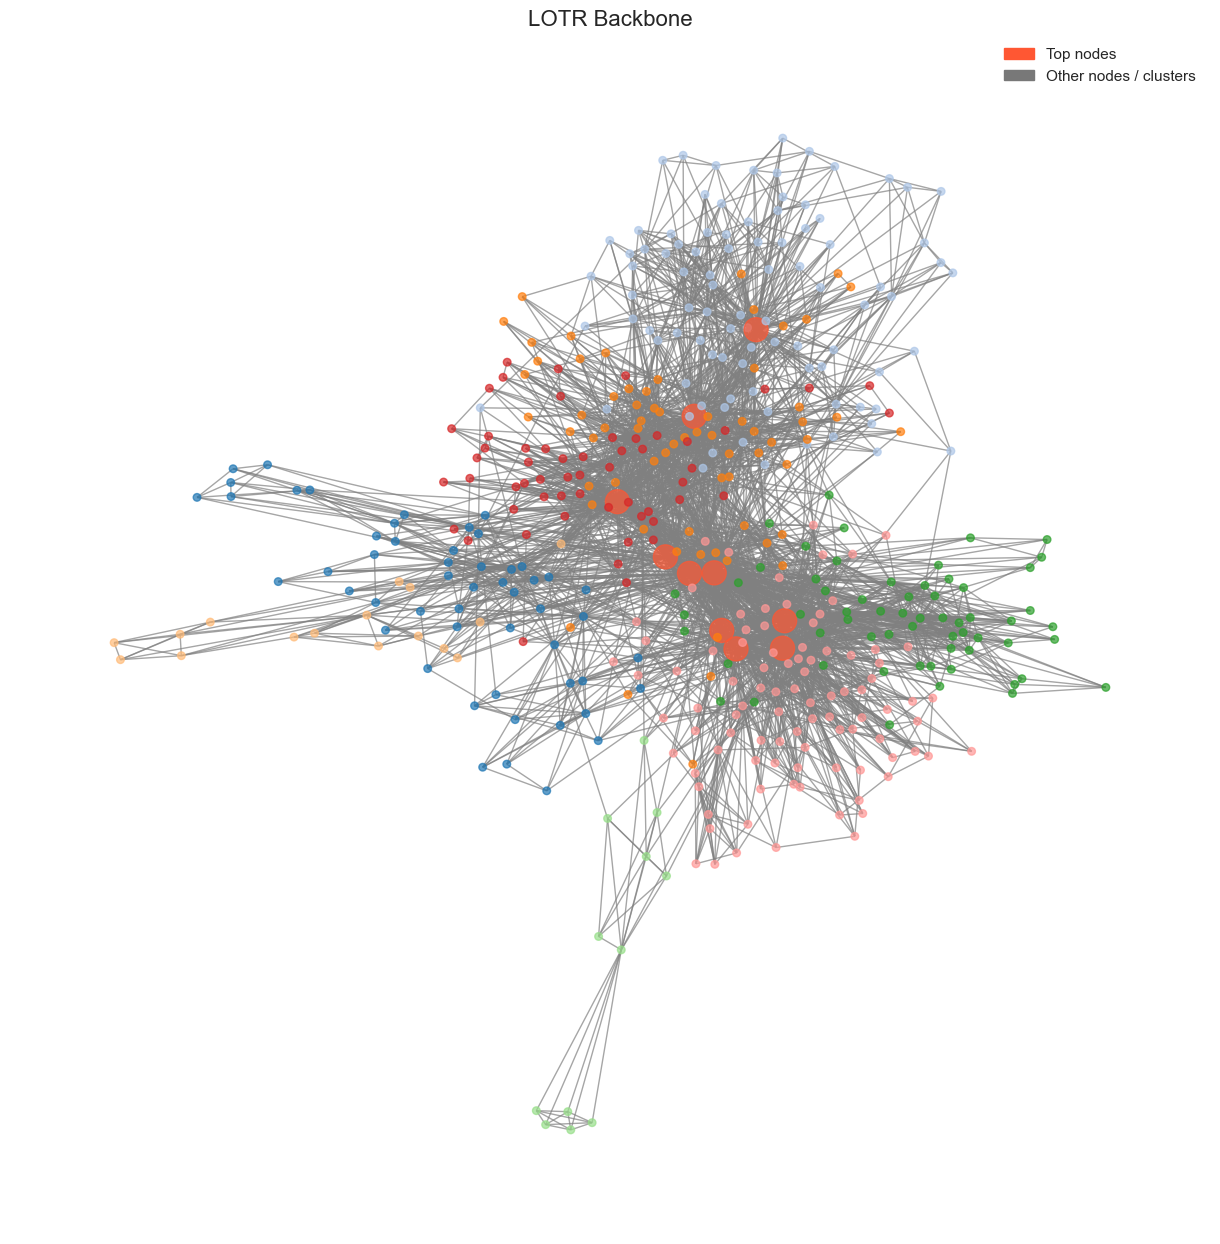

In [53]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import community

# --- Helper: get top N nodes by centrality ---
def get_top_nodes(centrality_dict, N=10):
    return sorted(centrality_dict, key=centrality_dict.get, reverse=True)[:N]

# --- Function to draw k-core backbone with top nodes highlighted ---
def draw_kcore_backbone(G, top_nodes, k=5, title="Network Backbone"):
    # Ensure undirected for backbone
    backbone = G.to_undirected().copy()
    
    # Extract k-core
    backbone = nx.k_core(backbone, k=k)
    
    # Louvain community detection
    clusters = community.louvain_communities(backbone, seed=42)
    cluster_map = {}
    for i, c in enumerate(clusters):
        for n in c:
            cluster_map[n] = i
    
    # Node color and size
    node_color = []
    node_size = []
    for n in backbone.nodes():
        if n in top_nodes:
            node_color.append("#ff5733")  # Highlight top nodes
            node_size.append(300)
        else:
            c = cluster_map.get(n, -1)
            node_color.append(plt.cm.tab20(c % 20) if c >= 0 else "#787878")
            node_size.append(30)
    
    # Layout
    pos = nx.spring_layout(backbone, seed=42)
    
    # Draw network
    plt.figure(figsize=(12, 12))
    nx.draw(
        backbone, pos,
        node_color=node_color,
        node_size=node_size,
        edge_color="gray",
        with_labels=False,
        alpha=0.7
    )
    
    # Legend
    legend_handles = [
        mpatches.Patch(color="#ff5733", label="Top nodes"),
        mpatches.Patch(color="#787878", label="Other nodes / clusters")
    ]
    plt.legend(handles=legend_handles, loc="upper right")
    plt.title(title, fontsize=16)
    plt.show()
    
    return backbone, cluster_map

# --- Harry Potter ---
top_HP = get_top_nodes(nx.degree_centrality(HP_network), N=10)
backbone_HP, cluster_map_HP = draw_kcore_backbone(HP_network, top_HP, k=5, title="Harry Potter Backbone")

# --- LOTR ---
top_LOTR = get_top_nodes(nx.degree_centrality(LOTR_network), N=10)
backbone_LOTR, cluster_map_LOTR = draw_kcore_backbone(LOTR_network, top_LOTR, k=5, title="LOTR Backbone")
